# Aggregate Results — 10-Run Mean ± Std Report

Run this notebook after completing all 10 runs of `Oscar_FT.ipynb`.

Expects files: `run_results/run_01.json` through `run_results/run_10.json`

Produces:
- Overall metrics table (mean ± std)
- Per-class F1 table (mean ± std)
- Loss / Accuracy / Macro-F1 curves with shaded ±1 std bands
- Gate weight convergence curves (3 fusion modules)
- Final gate weight table
- Aggregated confusion matrix (sum across all 10 runs, normalized)


## 1. Load All Run Results

In [1]:
import json
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

N_RUNS = 10
all_runs = []

for i in range(1, N_RUNS + 1):
    path = f"run_results/run_{i:02d}.json"
    if not os.path.exists(path):
        print(f"WARNING: {path} not found — skipping.")
        continue
    with open(path) as f:
        all_runs.append(json.load(f))

print(f"Loaded {len(all_runs)} runs.")
class_names = list(all_runs[0]["label_map"].keys())

Loaded 10 runs.


## 2. Overall Metrics Table (Mean ± Std)

In [2]:
metrics = {
    "Accuracy":        "unseen_acc",
    "Macro Precision": "unseen_prec",
    "Macro Recall":    "unseen_rec",
    "Macro F1":        "unseen_f1",
}

print("=" * 50)
print(f"{'Metric':<20} {'Mean':>10} {'Std':>10}")
print("=" * 50)
for name, key in metrics.items():
    vals = [r[key] for r in all_runs]
    print(f"{name:<20} {np.mean(vals):>10.4f} {np.std(vals):>10.4f}")
print("=" * 50)

Metric                     Mean        Std
Accuracy                 0.6171     0.0000
Macro Precision          0.3451     0.0000
Macro Recall             0.3723     0.0000
Macro F1                 0.3401     0.0000


## 3. Per-Class F1 Table (Mean ± Std)

In [3]:
print("=" * 55)
print(f"{'Class':<20} {'Mean F1':>10} {'Std F1':>10}")
print("=" * 55)
for cls in class_names:
    vals = [r["per_class_f1"][cls] for r in all_runs]
    print(f"{cls:<20} {np.mean(vals):>10.4f} {np.std(vals):>10.4f}")
print("=" * 55)

Class                   Mean F1     Std F1
Bronchiectasis           0.1765     0.0000
Bronchiolitis            0.2500     0.0000
COPD                     0.7845     0.0000
Healthy                  0.2500     0.0000
Pneumonia                0.3529     0.0000
URTI                     0.2264     0.0000


## 4. Select Best Fold History per Run

In [4]:
def get_best_fold_history(run):
    """Return the history of the fold with lowest best_val_loss."""
    best = min(run["fold_summaries"], key=lambda s: s["best_val_loss"])
    return best["history"]

histories = [get_best_fold_history(r) for r in all_runs]
min_epochs = min(len(h["train_loss"]) for h in histories)
epochs = np.arange(1, min_epochs + 1)
print(f"Aligned to {min_epochs} epochs across all runs.")


def mean_std_curve(key):
    curves = np.array([h[key][:min_epochs] for h in histories])
    return curves.mean(axis=0), curves.std(axis=0)

Aligned to 135 epochs across all runs.


## 5. Loss Curves

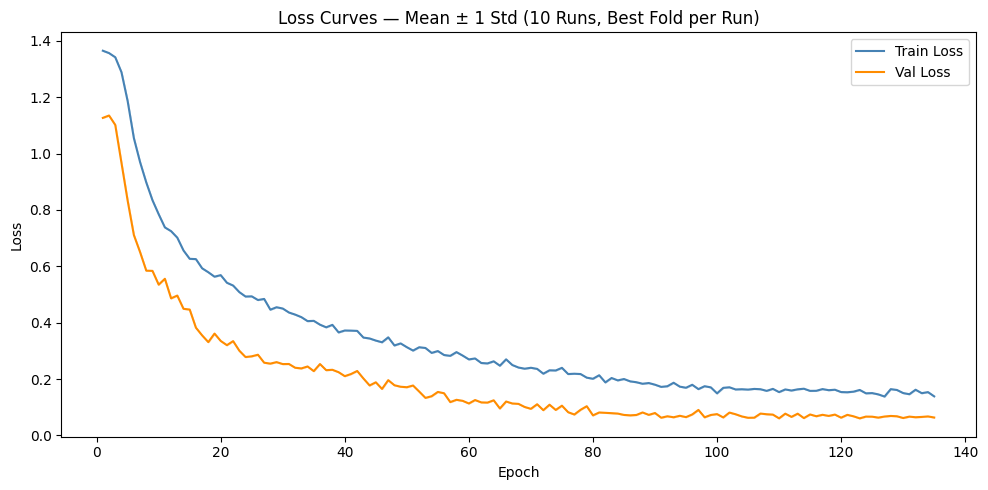

Saved: loss_curves.png


In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
for key, label, color in [
    ("train_loss", "Train Loss", "steelblue"),
    ("val_loss",   "Val Loss",   "darkorange")
]:
    mean, std = mean_std_curve(key)
    ax.plot(epochs, mean, label=label, color=color, linewidth=1.5)
    ax.fill_between(epochs, mean - std, mean + std, alpha=0.2, color=color)

ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.set_title("Loss Curves — Mean ± 1 Std (10 Runs, Best Fold per Run)")
ax.legend(); plt.tight_layout()
plt.savefig("loss_curves.png", dpi=150)
plt.show()
print("Saved: loss_curves.png")

## 6. Accuracy Curves

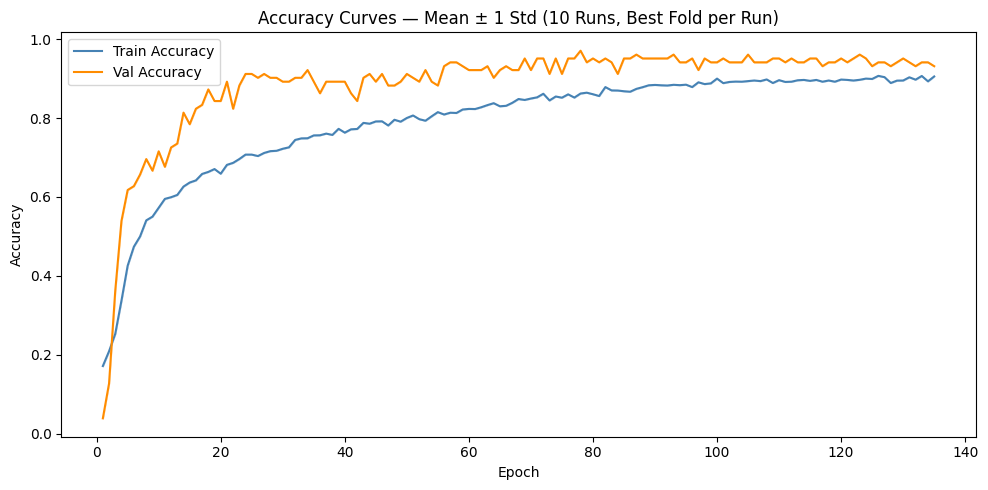

Saved: accuracy_curves.png


In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
for key, label, color in [
    ("train_acc", "Train Accuracy", "steelblue"),
    ("val_acc",   "Val Accuracy",   "darkorange")
]:
    mean, std = mean_std_curve(key)
    ax.plot(epochs, mean, label=label, color=color, linewidth=1.5)
    ax.fill_between(epochs, mean - std, mean + std, alpha=0.2, color=color)

ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy")
ax.set_title("Accuracy Curves — Mean ± 1 Std (10 Runs, Best Fold per Run)")
ax.legend(); plt.tight_layout()
plt.savefig("accuracy_curves.png", dpi=150)
plt.show()
print("Saved: accuracy_curves.png")

## 7. Macro-F1 Curves

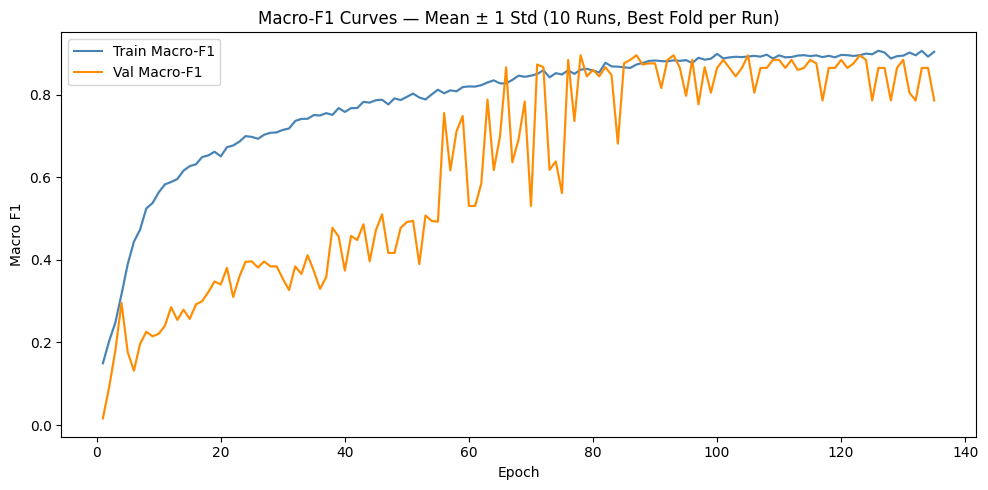

Saved: f1_curves.png


In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
for key, label, color in [
    ("train_f1", "Train Macro-F1", "steelblue"),
    ("val_f1",   "Val Macro-F1",   "darkorange")
]:
    mean, std = mean_std_curve(key)
    ax.plot(epochs, mean, label=label, color=color, linewidth=1.5)
    ax.fill_between(epochs, mean - std, mean + std, alpha=0.2, color=color)

ax.set_xlabel("Epoch"); ax.set_ylabel("Macro F1")
ax.set_title("Macro-F1 Curves — Mean ± 1 Std (10 Runs, Best Fold per Run)")
ax.legend(); plt.tight_layout()
plt.savefig("f1_curves.png", dpi=150)
plt.show()
print("Saved: f1_curves.png")

## 8. Gate Weight Convergence Curves

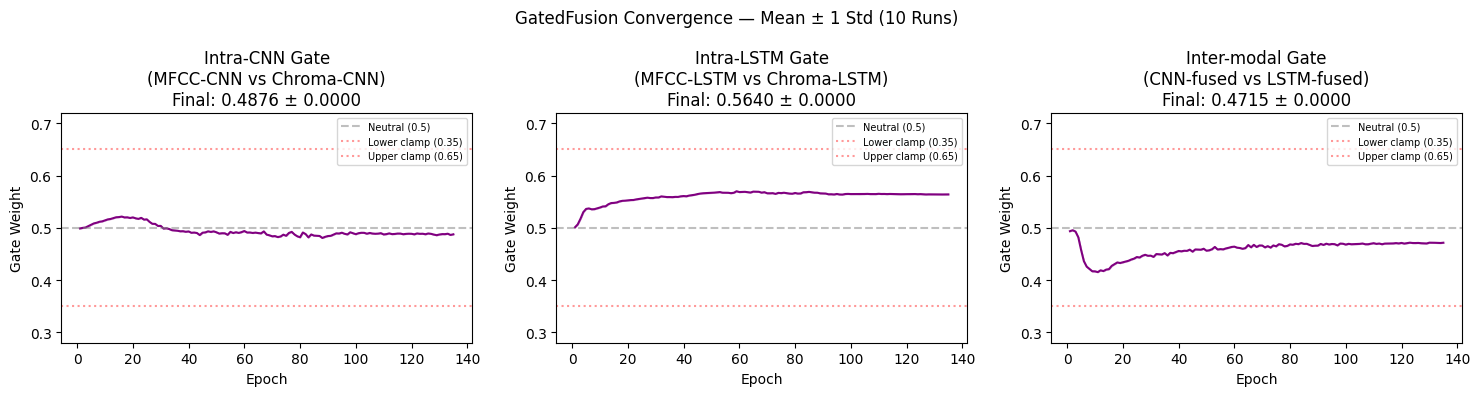

Saved: gate_curves.png


In [8]:
gate_configs = [
    ("val_w_cnn",   "Intra-CNN Gate\n(MFCC-CNN vs Chroma-CNN)"),
    ("val_w_lstm",  "Intra-LSTM Gate\n(MFCC-LSTM vs Chroma-LSTM)"),
    ("val_w_inter", "Inter-modal Gate\n(CNN-fused vs LSTM-fused)"),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (key, title) in zip(axes, gate_configs):
    mean, std = mean_std_curve(key)
    final_mean = mean[-1]
    final_std  = std[-1]

    ax.plot(epochs, mean, color="purple", linewidth=1.5)
    ax.fill_between(epochs, mean - std, mean + std, alpha=0.2, color="purple")
    ax.axhline(0.5, color="gray", linestyle="--", alpha=0.5, label="Neutral (0.5)")
    ax.axhline(0.35, color="red", linestyle=":", alpha=0.4, label="Lower clamp (0.35)")
    ax.axhline(0.65, color="red", linestyle=":", alpha=0.4, label="Upper clamp (0.65)")
    ax.set_ylim(0.28, 0.72)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Gate Weight")
    ax.set_title(f"{title}\nFinal: {final_mean:.4f} ± {final_std:.4f}")
    ax.legend(fontsize=7)

plt.suptitle("GatedFusion Convergence — Mean ± 1 Std (10 Runs)", fontsize=12)
plt.tight_layout()
plt.savefig("gate_curves.png", dpi=150)
plt.show()
print("Saved: gate_curves.png")

## 9. Final Gate Weight Table

In [9]:
print("=" * 60)
print(f"{'Fusion Module':<30} {'Final Mean':>12} {'Final Std':>12}")
print("=" * 60)
for key, name in [
    ("val_w_cnn",   "Intra-CNN Gate"),
    ("val_w_lstm",  "Intra-LSTM Gate"),
    ("val_w_inter", "Inter-modal Gate"),
]:
    finals = [h[key][-1] for h in histories]
    print(f"{name:<30} {np.mean(finals):>12.4f} {np.std(finals):>12.4f}")
print("=" * 60)

Fusion Module                    Final Mean    Final Std
Intra-CNN Gate                       0.4876       0.0000
Intra-LSTM Gate                      0.5640       0.0000
Inter-modal Gate                     0.4715       0.0000


## 10. Aggregated Confusion Matrix (Sum Across All 10 Runs)

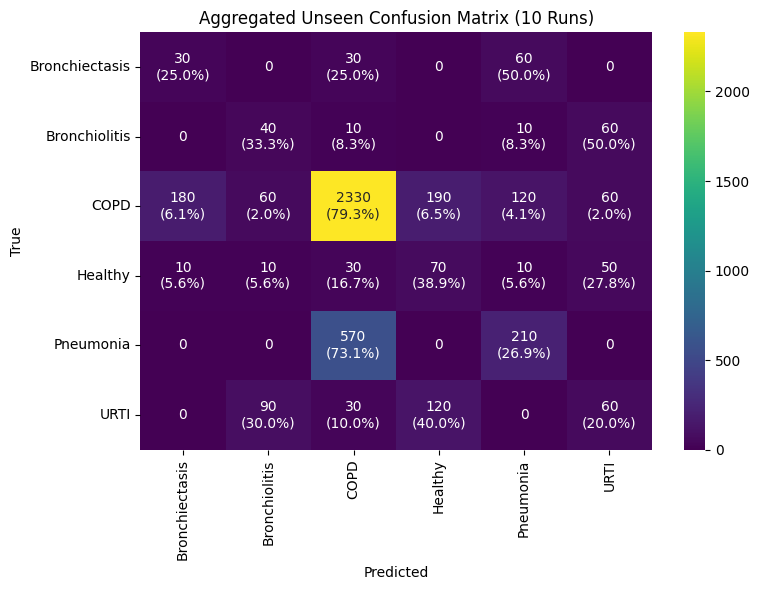

Saved: confusion_matrix_aggregated.png


In [10]:
agg_cm = np.zeros_like(np.array(all_runs[0]["confusion_matrix"]))
for r in all_runs:
    agg_cm += np.array(r["confusion_matrix"])

agg_cm_norm = agg_cm.astype("float") / agg_cm.sum(axis=1, keepdims=True)

annot = np.empty_like(agg_cm).astype(str)
for i in range(agg_cm.shape[0]):
    for j in range(agg_cm.shape[1]):
        count   = agg_cm[i, j]
        percent = agg_cm_norm[i, j] * 100
        annot[i, j] = "0" if count == 0 else f"{count}\n({percent:.1f}%)"

plt.figure(figsize=(8, 6))
sns.heatmap(agg_cm, annot=annot, fmt="", cmap="viridis",
            xticklabels=class_names, yticklabels=class_names, cbar=True)
plt.title(f"Aggregated Unseen Confusion Matrix ({len(all_runs)} Runs)")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout()
plt.savefig("confusion_matrix_aggregated.png", dpi=150)
plt.show()
print("Saved: confusion_matrix_aggregated.png")

## 11. Full Summary Report

In [11]:
print("\n" + "=" * 65)
print("OSCAR — 10-RUN AGGREGATED RESULTS SUMMARY")
print("=" * 65)

print("\n--- Overall Unseen Metrics ---")
for name, key in metrics.items():
    vals = [r[key] for r in all_runs]
    print(f"  {name:<20} {np.mean(vals):.4f} ± {np.std(vals):.4f}")

print("\n--- Per-Class F1 (Unseen) ---")
for cls in class_names:
    vals = [r["per_class_f1"][cls] for r in all_runs]
    print(f"  {cls:<20} {np.mean(vals):.4f} ± {np.std(vals):.4f}")

print("\n--- Final Gate Weights ---")
for key, name in [
    ("val_w_cnn",   "Intra-CNN"),
    ("val_w_lstm",  "Intra-LSTM"),
    ("val_w_inter", "Inter-modal"),
]:
    finals = [h[key][-1] for h in histories]
    print(f"  {name:<20} {np.mean(finals):.4f} ± {np.std(finals):.4f}")

print("\n--- Individual Run Results ---")
for r in all_runs:
    print(f"  Run {r['run_id']:02d}: Acc={r['unseen_acc']:.4f} | F1={r['unseen_f1']:.4f}")

print("=" * 65)


OSCAR — 10-RUN AGGREGATED RESULTS SUMMARY

--- Overall Unseen Metrics ---
  Accuracy             0.6171 ± 0.0000
  Macro Precision      0.3451 ± 0.0000
  Macro Recall         0.3723 ± 0.0000
  Macro F1             0.3401 ± 0.0000

--- Per-Class F1 (Unseen) ---
  Bronchiectasis       0.1765 ± 0.0000
  Bronchiolitis        0.2500 ± 0.0000
  COPD                 0.7845 ± 0.0000
  Healthy              0.2500 ± 0.0000
  Pneumonia            0.3529 ± 0.0000
  URTI                 0.2264 ± 0.0000

--- Final Gate Weights ---
  Intra-CNN            0.4876 ± 0.0000
  Intra-LSTM           0.5640 ± 0.0000
  Inter-modal          0.4715 ± 0.0000

--- Individual Run Results ---
  Run 01: Acc=0.6171 | F1=0.3401
  Run 02: Acc=0.6171 | F1=0.3401
  Run 03: Acc=0.6171 | F1=0.3401
  Run 04: Acc=0.6171 | F1=0.3401
  Run 05: Acc=0.6171 | F1=0.3401
  Run 06: Acc=0.6171 | F1=0.3401
  Run 07: Acc=0.6171 | F1=0.3401
  Run 08: Acc=0.6171 | F1=0.3401
  Run 09: Acc=0.6171 | F1=0.3401
  Run 10: Acc=0.6171 | F1=0.34